In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import sys
from pathlib import Path
import random
import numpy as np

# Make sure src is importable
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root / 'src'))
from etc import Hamiltonian

##### Node label convertion

In [2]:
def G_string_of_pearls(m=7, clique=8):
    parts = [nx.complete_graph(clique) for _ in range(m)]
    G = nx.disjoint_union_all(parts)
    offset = 0
    for i in range(m-1):
        a = offset + clique - 1
        b = offset + clique
        G.add_edge(a, b)
        offset += clique
    return nx.convert_node_labels_to_integers(G, ordering="sorted")

##### Keep connected components

In [3]:
def connect_components(G, seed=1):
    if nx.is_connected(G):
        return nx.convert_node_labels_to_integers(G, ordering="sorted")
    rng = random.Random(seed)
    components = [list(c) for c in nx.connected_components(G)]
    for i in range(len(components)-1):
        u = rng.choice(components[i])
        v = rng.choice(components[i+1])
        G.add_edge(u, v)
    return nx.convert_node_labels_to_integers(G, ordering="sorted")

def smart_layout(G):
    n = G.number_of_nodes()
    if n <= 1200:
        try: 
            return nx.kamada_kawai_layout(G)
        except Exception:
            return nx.spring_layout(G, seed=1)
    return nx.spectral_layout(G)

#### Visualization of the graph

In [4]:
def show_graph(G, title=None, node_size=8):
    pos = smart_layout(G)
    plt.figure(figsize=(7, 7))
    nx.draw_networkx_nodes(G, pos, node_size=node_size)
    nx.draw_networkx_edges(G, pos, width=0.3)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

### List of different graphs models

In [5]:
graphs = [
    ("Barbell(c=25, p=5)",        nx.barbell_graph(25, 5)),
    ("Lollipop(c=30, t=50)",      nx.lollipop_graph(30, 50)),
    ("String of Pearls(m=7,c=8)", G_string_of_pearls(7, 8)),
    ("Path(n=300)",               nx.path_graph(20)),
    ("Balanced Tree(r=3,h=5)",    nx.balanced_tree(3, 5)),
    ("Core-Periphery",            connect_components(nx.stochastic_block_model([80, 220], [[0.18, 0.05],[0.05, 0.01]], seed=2), seed=2)),
    ("WS beta=0.0",               connect_components(nx.watts_strogatz_graph(150, 8, 0.0, seed=2), seed=2)),
    ("WS beta=0.2",               connect_components(nx.watts_strogatz_graph(150, 8, 0.2, seed=2), seed=2)),
    ("WS beta=1.0",               connect_components(nx.watts_strogatz_graph(150, 8, 1.0, seed=2), seed=2)),
    ("BA(n=400,m=2)",             nx.barabasi_albert_graph(100, 2, seed=2)),
    ("Powerlaw-Cluster",          connect_components(nx.powerlaw_cluster_graph(100, 2, 0.3, seed=2), seed=2)),
    ("d-Regular(n=400,d=6)",      connect_components(nx.random_regular_graph(6, 100, seed=2), seed=2)),
    ("Geometric(n=400,r=0.07)",   connect_components(nx.random_geometric_graph(100, 0.07, seed=2), seed=2)),
    ("Star(n=400)",               nx.star_graph(50)),
]

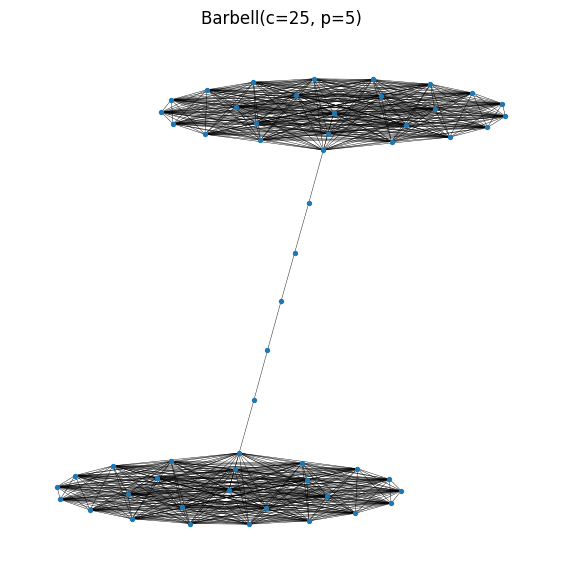

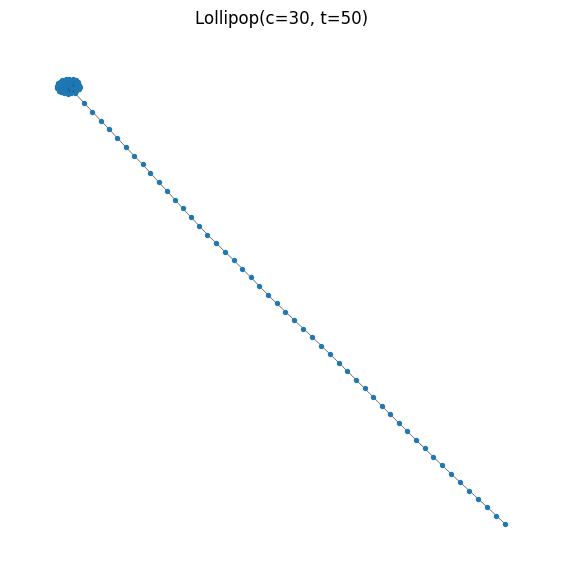

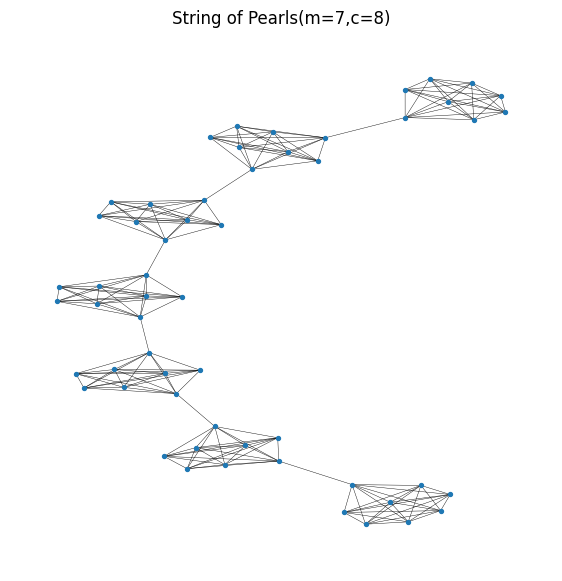

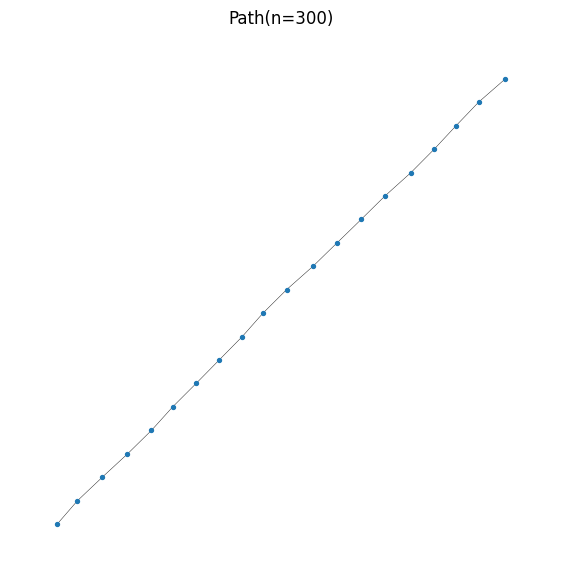

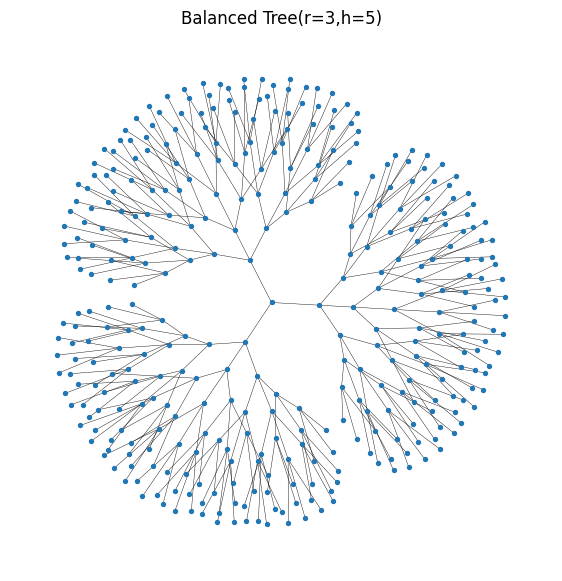

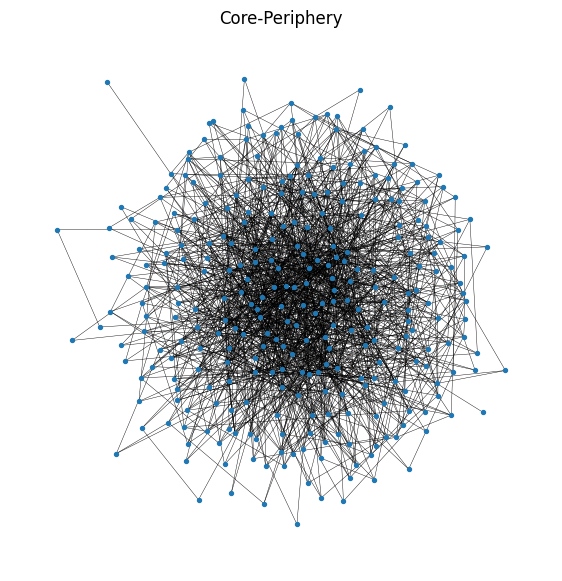

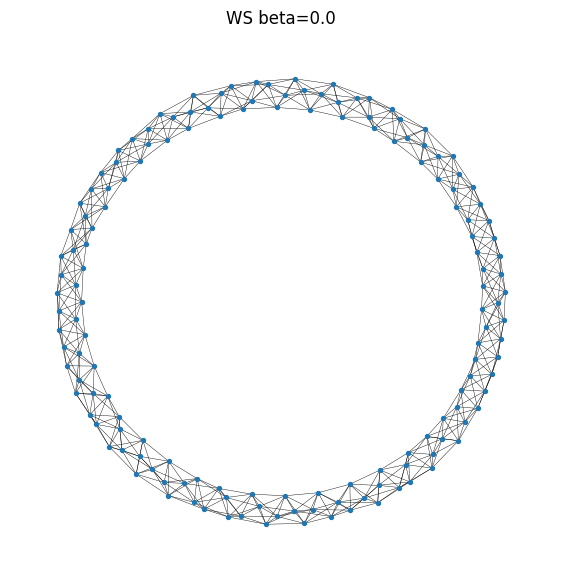

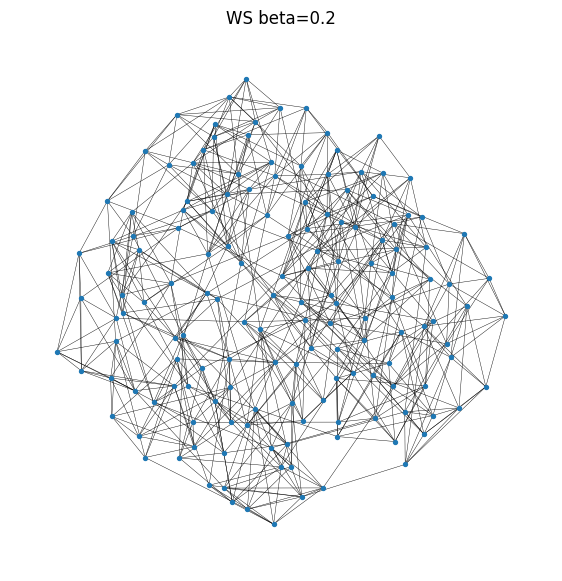

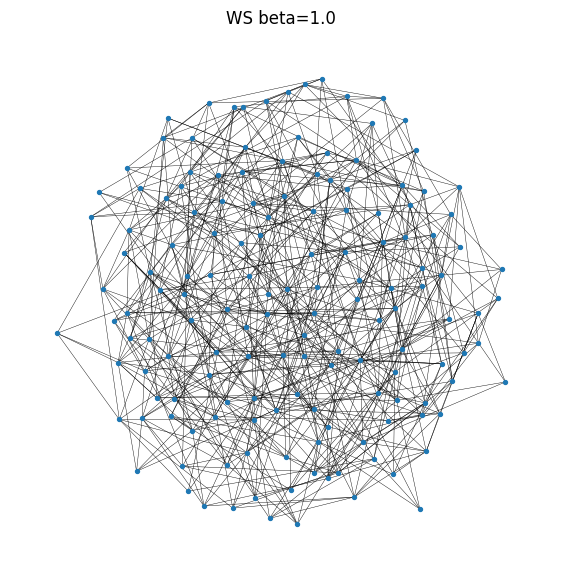

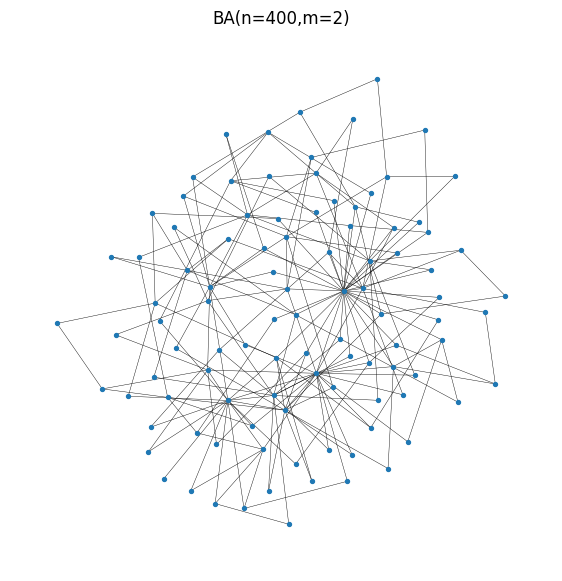

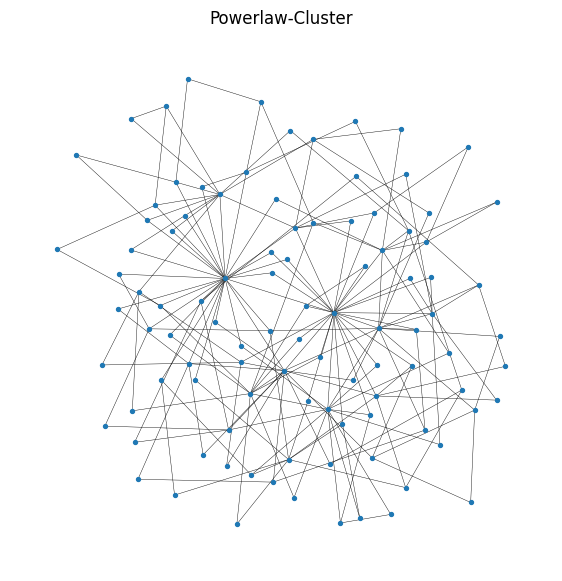

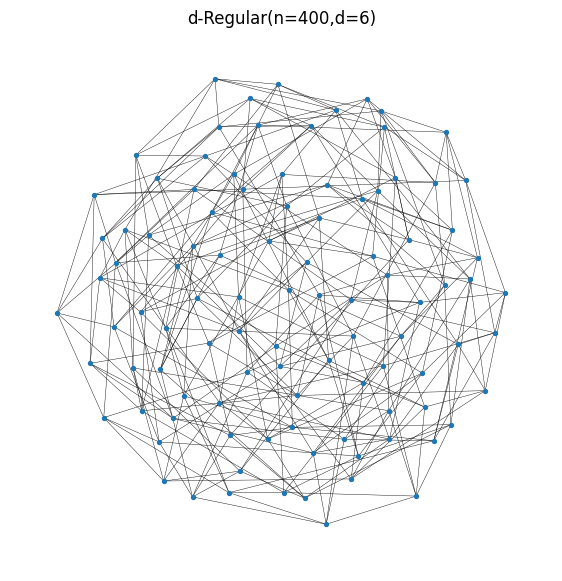

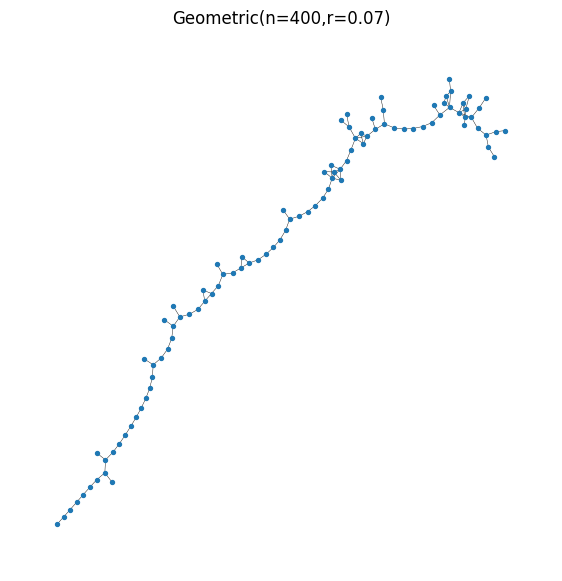

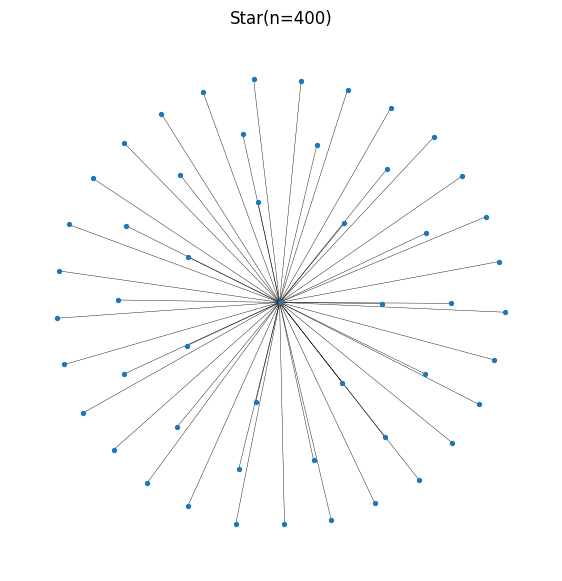

In [6]:
import os
import json

# Ensure the 'data' directory exists
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

def stringify_attr(val):
    """Return a string-safe representation for GML.

    - Strings are left as-is.
    - Other objects are JSON-dumped when possible, falling back to str().
    This handles sets, lists, dicts, numbers, etc.
    """
    if isinstance(val, str):
        return val
    try:
        return json.dumps(val, default=str)
    except Exception:
        return str(val)

for name, G in graphs:
    Gc = connect_components(G)  # ensure connectivity
    ns = 6 if Gc.number_of_nodes() > 600 else 8
    show_graph(Gc, title=name, node_size=ns)
    
    # Save the graph as a GML file
    safe_name = name.replace(' ', '_').replace('=', '').replace('(', '').replace(')', '').replace(',', '_')
    file_path = os.path.join(data_dir, f"{safe_name}.gml")
    
    # Convert node labels to strings for GML compatibility
    Gc_str = nx.relabel_nodes(Gc, lambda x: str(x))

    # Convert graph-level attributes
    for k, v in list(Gc_str.graph.items()):
        Gc_str.graph[k] = stringify_attr(v)

    # Convert node attributes
    for node, attributes in Gc_str.nodes(data=True):
        for key in list(attributes.keys()):
            attributes[key] = stringify_attr(attributes[key])

    # Convert edge attributes
    for u, v, attributes in Gc_str.edges(data=True):
        for key in list(attributes.keys()):
            attributes[key] = stringify_attr(attributes[key])

    nx.write_gml(Gc_str, file_path)

In [7]:
# experiment parameters
k = 30            # nodes per subset
n_trials = 1000   # how many random subsets to sample
mu = 1.0
gamma = None      # let the class choose gamma (set float to override)

rng = random.Random(12345)

summary = {}

for name, G in graphs:
    # ensure connectivity and integer node labels (same as earlier)
    Gc = connect_components(G)
    n = Gc.number_of_nodes()
    if n < k:
        print(f"Skipping '{name}': graph has {n} nodes (< {k})")
        continue

    print(f"Running: {name} (n={n})")
    Hobj = Hamiltonian(Gc)  # will precompute distances and Dinv2_triu

    indices = list(range(n))
    values = np.empty(n_trials, dtype=np.float64)
    t1_vals = np.empty(n_trials, dtype=np.float64)
    t2_vals = np.empty(n_trials, dtype=np.float64)
    subsets = [None] * n_trials

    for i in range(n_trials):
        S = rng.sample(indices, k)
        val, t1, t2 = Hobj.compute(S, mu=mu, gamma=gamma)
        values[i] = val
        t1_vals[i] = t1
        t2_vals[i] = t2
        subsets[i] = S

    imin = int(np.argmin(values))
    imax = int(np.argmax(values))

    summary[name] = {
        "min": float(values[imin]),
        "min_idx": imin,
        "min_subset": subsets[imin],
        "max": float(values[imax]),
        "max_idx": imax,
        "max_subset": subsets[imax],
        "mean": float(values.mean()),
        "std": float(values.std()),
    }

    print(
        f"  H min={summary[name]['min']:.6g} (trial {imin}), "
        f"max={summary[name]['max']:.6g} (trial {imax}), mean={summary[name]['mean']:.6g}"
    )

# Optionally: inspect one graph's histogram (e.g., first in summary)
if summary:
    first = next(iter(summary))
    print("\nSummary sample for:", first)
    print(summary[first])

Running: Barbell(c=25, p=5) (n=55)
  H min=2204.24 (trial 583), max=6119.59 (trial 837), mean=3923.17
Running: Lollipop(c=30, t=50) (n=80)
  H min=5208.47 (trial 240), max=40851.7 (trial 18), mean=17100.7
Running: String of Pearls(m=7,c=8) (n=56)
  H min=541.121 (trial 439), max=1342.32 (trial 505), mean=949.748
Skipping 'Path(n=300)': graph has 20 nodes (< 30)
Running: Balanced Tree(r=3,h=5) (n=364)
  H min=-3.90912 (trial 971), max=4.44477 (trial 252), mean=0.887586
Running: Core-Periphery (n=300)
  H min=2.4257 (trial 903), max=40.6563 (trial 585), mean=22.8226
Running: WS beta=0.0 (n=150)
  H min=199.078 (trial 331), max=567.43 (trial 830), mean=356.116
Running: WS beta=0.2 (n=150)
  H min=7.14972 (trial 302), max=44.4204 (trial 542), mean=28.0954
Running: WS beta=1.0 (n=150)
  H min=-8.41056 (trial 584), max=34.721 (trial 305), mean=17.009
Running: BA(n=400,m=2) (n=100)
  H min=-0.643406 (trial 129), max=42.9016 (trial 408), mean=20.3884
Running: Powerlaw-Cluster (n=100)
  H min=-

In [7]:
# experiment parameters
k = 10            # nodes per subset
n_trials = 1000   # how many random subsets to sample
gamma = 43.39      # let the class choose gamma (set float to override)
mu = 1.0
rng = random.Random(12345)

summary = {}


# ensure connectivity and integer node labels (same as earlier)
Gc = connect_components(graphs[0][1])
n = Gc.number_of_nodes()
#mu = Hobj.mu_density_aware(Gc)
print(f"Running: {graphs[0][0]} (n={n})")
Hobj = Hamiltonian(Gc)  # will precompute distances and Dinv2_triu

indices = list(range(n))
values = np.empty(n_trials, dtype=np.float64)
t1_vals = np.empty(n_trials, dtype=np.float64)
t2_vals = np.empty(n_trials, dtype=np.float64)
subsets = [None] * n_trials

for i in range(n_trials):
    S = rng.sample(indices, k)
    val, t1, t2 = Hobj.compute(S, mu=mu, gamma=gamma)
    values[i] = val
    t1_vals[i] = t1
    t2_vals[i] = t2
    subsets[i] = S

imin = int(np.argmin(values))
imax = int(np.argmax(values))

summary['Barbell(c=25, p=5)'] = {
    "min": float(values[imin]),
    "min_idx": imin,
    "min_subset": subsets[imin],
    "max": float(values[imax]),
    "max_idx": imax,
    "max_subset": subsets[imax],
    "mean": float(values.mean()),
    "std": float(values.std()),
}

print(
    f"  H min={summary['Barbell(c=25, p=5)']['min']:.6g} (trial {imin}), "
    f"max={summary['Barbell(c=25, p=5)']['max']:.6g} (trial {imax}), mean={summary['Barbell(c=25, p=5)']['mean']:.6g}"
)

Running: Barbell(c=25, p=5) (n=55)
  H min=45.9211 (trial 994), max=1023.21 (trial 874), mean=397.142


In [8]:
# Use the gamma_balancer to compute a suitable gamma value
Hobj.gamma_balancer()

44.122866894197955

In [15]:
graphs[2][1]

In [16]:
Hobj.Dinv2_triu

array([[0.      , 1.      , 1.      , ..., 0.015625, 0.015625, 0.015625],
       [0.      , 0.      , 1.      , ..., 0.015625, 0.015625, 0.015625],
       [0.      , 0.      , 0.      , ..., 0.015625, 0.015625, 0.015625],
       ...,
       [0.      , 0.      , 0.      , ..., 0.      , 1.      , 1.      ],
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 1.      ],
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ]],
      shape=(55, 55))

In [17]:
max(nx.all_pairs_shortest_path_length(Gc))

(54,
 {54: 0,
  30: 1,
  31: 1,
  32: 1,
  33: 1,
  34: 1,
  35: 1,
  36: 1,
  37: 1,
  38: 1,
  39: 1,
  40: 1,
  41: 1,
  42: 1,
  43: 1,
  44: 1,
  45: 1,
  46: 1,
  47: 1,
  48: 1,
  49: 1,
  50: 1,
  51: 1,
  52: 1,
  53: 1,
  29: 2,
  28: 3,
  27: 4,
  26: 5,
  25: 6,
  24: 7,
  0: 8,
  1: 8,
  2: 8,
  3: 8,
  4: 8,
  5: 8,
  6: 8,
  7: 8,
  8: 8,
  9: 8,
  10: 8,
  11: 8,
  12: 8,
  13: 8,
  14: 8,
  15: 8,
  16: 8,
  17: 8,
  18: 8,
  19: 8,
  20: 8,
  21: 8,
  22: 8,
  23: 8})